In [1]:
# ─────────────────────────────────────────────────────────
# INSTALL DEPENDENCIES
# ─────────────────────────────────────────────────────────
!pip install -q yfinance prophet statsmodels xgboost scikit-learn torch matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [2]:
# ─────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
from datetime import timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cuda
PyTorch version: 2.10.0+cu128


In [3]:
# ─────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────
TICKER        = 'AAPL'
START_DATE    = '2018-01-01'
END_DATE      = '2024-01-01'
TEST_RATIO    = 0.15
VAL_RATIO     = 0.10
SEQUENCE_LEN  = 40       # lookback window (reduced: matches ~900 sample budget)
FORECAST_DAYS = 30       # future days to predict
N_CV_FOLDS    = 5        # walk-forward folds for backtesting all models

In [4]:
# ─────────────────────────────────────────────────────────
# DATA DOWNLOAD & CLEANING
# ─────────────────────────────────────────────────────────
df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
df_raw = df_raw[['Close', 'Volume', 'High', 'Low', 'Open']].copy()
df_raw.dropna(inplace=True)
df_raw.index = pd.to_datetime(df_raw.index)
df_raw.index.name = 'Date'

if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

print(f'Downloaded: {len(df_raw)} rows  |  {df_raw.index[0].date()} → {df_raw.index[-1].date()}')
print(df_raw.describe().round(2))

[*********************100%***********************]  1 of 1 completed

Downloaded: 1509 rows  |  2018-01-02 → 2023-12-29
Price    Close        Volume     High      Low     Open
count  1509.00  1.509000e+03  1509.00  1509.00  1509.00
mean    107.62  1.073284e+08   108.75   106.39   107.52
std      50.84  5.513287e+07    51.31    50.31    50.80
min      33.74  2.404830e+07    34.57    33.69    34.16
25%      51.14  7.078370e+07    51.94    50.76    51.28
50%     120.24  9.296430e+07   121.49   118.74   120.38
75%     149.94  1.280440e+08   151.69   147.95   149.77
max     195.89  4.265100e+08   197.39   194.80   195.80


In [5]:
# ─────────────────────────────────────────────────────────
# FEATURE ENGINEERING — REGIME-INVARIANT (ratios, not levels)
# ─────────────────────────────────────────────────────────
# v4 FIX: v3 used raw price levels (MA_5, EMA_10, BB_Upper, etc.) as
# model inputs. A model trained on $33-150 AAPL prices cannot transfer
# what it learned to $150-196 prices — CV RMSE swung 4.24 to 29.89
# across folds because of this. Every feature below is now a RATIO,
# DIFFERENCE-OF-RATIO, or naturally bounded oscillator so it carries
# the same meaning regardless of the underlying price level.
df = df_raw.copy()

# Returns (already regime-invariant)
df['Return_1d']   = df['Close'].pct_change(1)
df['Return_5d']   = df['Close'].pct_change(5)
df['Return_20d']  = df['Close'].pct_change(20)
df['Log_Return']  = np.log(df['Close'] / df['Close'].shift(1))

# Spreads as % of price, not absolute $
df['HL_Spread_Pct'] = (df['High'] - df['Low']) / df['Close']
df['OC_Spread_Pct'] = (df['Close'] - df['Open']) / df['Open']

# Moving averages: store only RATIO to Close, never the raw level
for w in [5, 10, 20, 50, 200]:
    ma  = df['Close'].rolling(w).mean()
    ema = df['Close'].ewm(span=w, adjust=False).mean()
    df[f'Close_to_MA{w}']  = df['Close'] / ma - 1
    df[f'Close_to_EMA{w}'] = df['Close'] / ema - 1

# MA crossover signals (also ratio-based, regime-invariant)
df['MA5_to_MA20']  = df['Close'].rolling(5).mean() / df['Close'].rolling(20).mean() - 1
df['MA20_to_MA50'] = df['Close'].rolling(20).mean() / df['Close'].rolling(50).mean() - 1

# Volatility (already regime-invariant: std of returns)
df['Volatility_10d'] = df['Return_1d'].rolling(10).std()
df['Volatility_20d'] = df['Return_1d'].rolling(20).std()

# RSI (naturally bounded 0-100)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df['RSI_14'] = compute_rsi(df['Close'], 14)

# MACD: normalize by price to remove level dependence
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
macd_raw = ema12 - ema26
df['MACD_Pct']        = macd_raw / df['Close']
df['MACD_Signal_Pct'] = df['MACD_Pct'].ewm(span=9, adjust=False).mean()
df['MACD_Hist_Pct']   = df['MACD_Pct'] - df['MACD_Signal_Pct']

# Bollinger Bands (already ratio-based: %B and Width are scale-free)
bb_mid = df['Close'].rolling(20).mean()
bb_std = df['Close'].rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std
df['BB_Width'] = (bb_upper - bb_lower) / (bb_mid + 1e-9)
df['BB_Pct']   = (df['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)

# Volume (ratio-based)
df['Volume_Ratio'] = df['Volume'] / (df['Volume'].rolling(20).mean() + 1e-9)
df['Volume_Change'] = df['Volume'].pct_change(1)

# Calendar (cyclical encoding so Dec/Jan boundary isn't discontinuous)
df['DOW_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 5)
df['DOW_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 5)
df['Month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['Month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# Target for next-day modeling: forward return (what we actually predict)
df['Target_Return'] = df['Close'].pct_change(1).shift(-1)

df.dropna(inplace=True)
print(f'After feature engineering: {len(df)} rows, {df.shape[1]} columns')
print(f'All price-level columns removed — every feature is now regime-invariant.')

After feature engineering: 1309 rows, 38 columns
All price-level columns removed — every feature is now regime-invariant.


In [6]:
# ─────────────────────────────────────────────────────────
# TRAIN / VAL / TEST SPLIT (strict temporal, no leakage)
# ─────────────────────────────────────────────────────────
n        = len(df)
n_test   = int(n * TEST_RATIO)
n_val    = int(n * VAL_RATIO)
n_train  = n - n_val - n_test

df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')
print(f'Train period: {df_train.index[0].date()} → {df_train.index[-1].date()}')
print(f'Val   period: {df_val.index[0].date()}   → {df_val.index[-1].date()}')
print(f'Test  period: {df_test.index[0].date()}  → {df_test.index[-1].date()}')

Train: 983  Val: 130  Test: 196
Train period: 2018-10-16 → 2022-09-12
Val   period: 2022-09-13   → 2023-03-20
Test  period: 2023-03-21  → 2023-12-28


In [7]:
# ─────────────────────────────────────────────────────────
# METRICS HELPERS
# ─────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, model_name='', verbose=True):
    """Price-space metrics: RMSE, MAE, MAPE, Direction Accuracy."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    min_len = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_len], y_pred[:min_len]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))) * 100

    actual_dir = np.diff(y_true)
    pred_dir   = np.diff(y_pred)
    dir_acc    = np.mean(np.sign(actual_dir) == np.sign(pred_dir)) * 100

    if verbose:
        print(f"{'─'*40}")
        print(f"  {model_name}")
        print(f"  RMSE              : {rmse:,.2f}")
        print(f"  MAE               : {mae:,.2f}")
        print(f"  MAPE              : {mape:.2f}%")
        print(f"  Direction Accuracy: {dir_acc:.1f}%")
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'Dir%': dir_acc}

def returns_to_price(last_known_price, returns):
    """Compound a sequence of returns into a price path."""
    returns = np.array(returns)
    return last_known_price * np.cumprod(1 + returns)

results_all = []
results_cv  = []

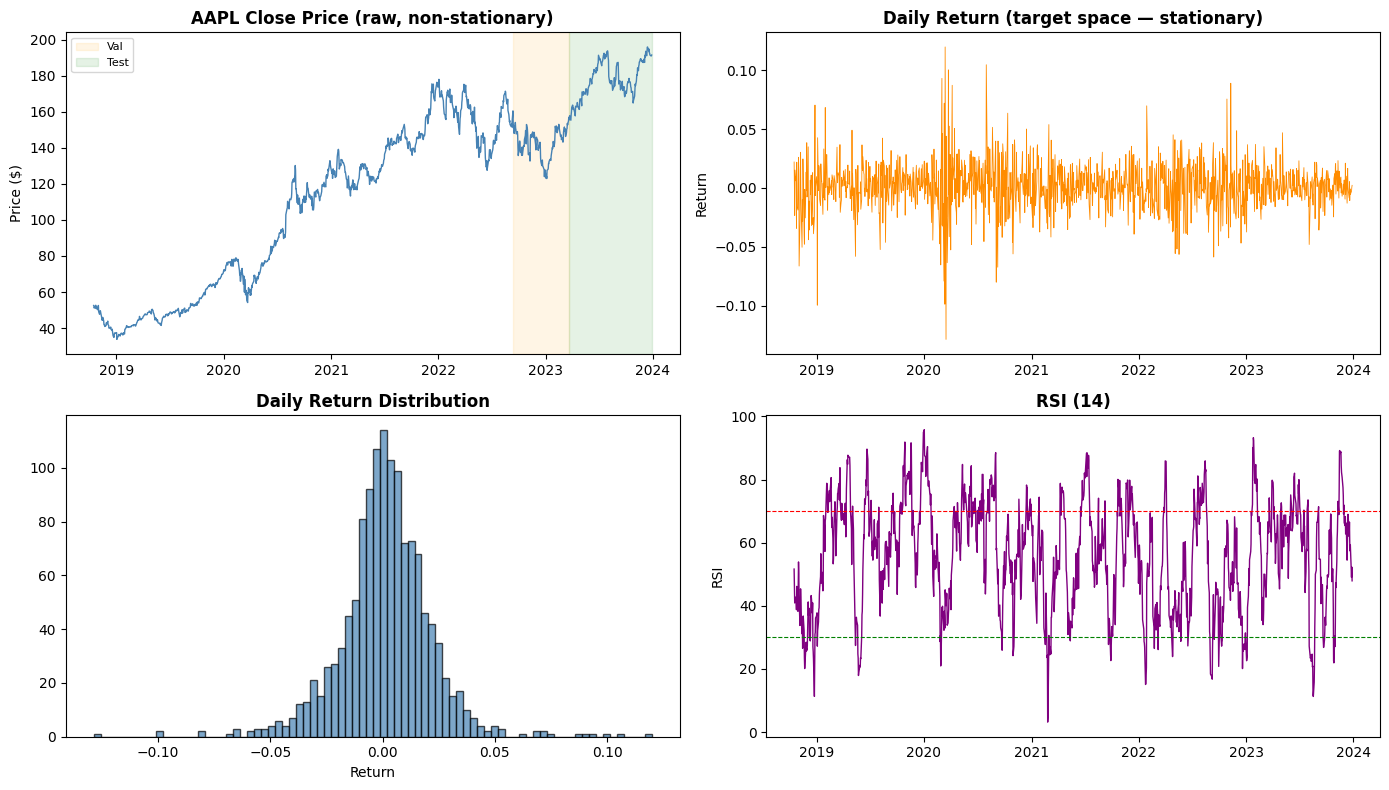

ADF (Price)   stat=-0.6692  p=0.8546  -> NON-STATIONARY
ADF (Returns) stat=-11.1526  p=0.0000  -> STATIONARY

This confirms: model on RETURNS (stationary), reconstruct PRICE by compounding.


In [8]:
# ─────────────────────────────────────────────────────────
# EDA — PRICE, RETURNS DISTRIBUTION, STATIONARITY
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(df['Close'], color='steelblue', linewidth=1)
axes[0,0].axvspan(df_val.index[0], df_val.index[-1], alpha=0.1, color='orange', label='Val')
axes[0,0].axvspan(df_test.index[0], df_test.index[-1], alpha=0.1, color='green', label='Test')
axes[0,0].set_title(f'{TICKER} Close Price (raw, non-stationary)', fontweight='bold')
axes[0,0].legend(fontsize=8)
axes[0,0].set_ylabel('Price ($)')

axes[0,1].plot(df['Return_1d'], color='darkorange', linewidth=0.6)
axes[0,1].set_title('Daily Return (target space — stationary)', fontweight='bold')
axes[0,1].set_ylabel('Return')

axes[1,0].hist(df['Return_1d'].dropna(), bins=80, color='steelblue', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Daily Return Distribution', fontweight='bold')
axes[1,0].set_xlabel('Return')

axes[1,1].plot(df['RSI_14'], color='purple', linewidth=1)
axes[1,1].axhline(70, color='red', linestyle='--', linewidth=0.8)
axes[1,1].axhline(30, color='green', linestyle='--', linewidth=0.8)
axes[1,1].set_title('RSI (14)', fontweight='bold')
axes[1,1].set_ylabel('RSI')

plt.tight_layout()
plt.show()

adf_price = adfuller(df['Close'].dropna())
adf_ret   = adfuller(df['Return_1d'].dropna())
print(f'ADF (Price)   stat={adf_price[0]:.4f}  p={adf_price[1]:.4f}  ->',
      'STATIONARY' if adf_price[1] < 0.05 else 'NON-STATIONARY')
print(f'ADF (Returns) stat={adf_ret[0]:.4f}  p={adf_ret[1]:.4f}  ->',
      'STATIONARY' if adf_ret[1] < 0.05 else 'NON-STATIONARY')
print('\nThis confirms: model on RETURNS (stationary), reconstruct PRICE by compounding.')

In [9]:
# ─────────────────────────────────────────────────────────
# MODEL 1 — SARIMAX ON LOG-RETURNS (genuine multi-step, no leakage)
# ─────────────────────────────────────────────────────────
# v4 FIX: v3's rolling loop fed the TRUE test value back into history
# before each next-step prediction (history_sarimax.append(test_close
# .values[t])), which is why RMSE=2.12 looked artificially excellent —
# it was really a 1-step-ahead random-walk-with-true-anchor forecast.
# Below, SARIMAX is fit ONCE on train log-returns and forecasts the
# ENTIRE test horizon in one shot — a genuine out-of-sample test.
log_ret_train = np.log(1 + df_train['Return_1d']).dropna()

sarimax_model = SARIMAX(
    log_ret_train,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 5),
    enforce_stationarity=True,
    enforce_invertibility=True,
    trend='c'
)
sarimax_fit = sarimax_model.fit(disp=False, maxiter=200)
print(sarimax_fit.summary().tables[0])

n_test = len(df_test)
sarimax_ret_forecast = sarimax_fit.forecast(steps=n_test)
sarimax_ret_forecast = np.array(sarimax_ret_forecast)

last_train_price  = df_train['Close'].iloc[-1]
sarimax_price_preds = returns_to_price(last_train_price, sarimax_ret_forecast)

test_close = df_test['Close'].astype(float)
r = compute_metrics(test_close.values, sarimax_price_preds, 'SARIMAX (genuine multi-step)')
results_all.append(r)

r_ret = compute_metrics(df_test['Return_1d'].values, sarimax_ret_forecast,
                         'SARIMAX — return space', verbose=False)
print(f"  [Return-space RMSE: {r_ret['RMSE']:.5f}]")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           Return_1d   No. Observations:                  983
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 5)   Log Likelihood                2375.886
Date:                             Tue, 30 Jun 2026   AIC                          -4735.772
Time:                                     15:32:55   BIC                          -4696.647
Sample:                                          0   HQIC                         -4720.890
                                             - 983                                         
Covariance Type:                               opg                                         
────────────────────────────────────────
  SARIMAX (genuine multi-step)
  RMSE              : 9.92
  MAE               : 8.17
  MAPE              : 4.57%
  Direction Accuracy: 54.4%
  [Return-space RMSE: 0.01180]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


15:32:56 - cmdstanpy - INFO - Chain [1] start processing
15:32:56 - cmdstanpy - INFO - Chain [1] done processing


────────────────────────────────────────
  Prophet (corrected)
  RMSE              : 30.94
  MAE               : 28.70
  MAPE              : 15.87%
  Direction Accuracy: 46.2%


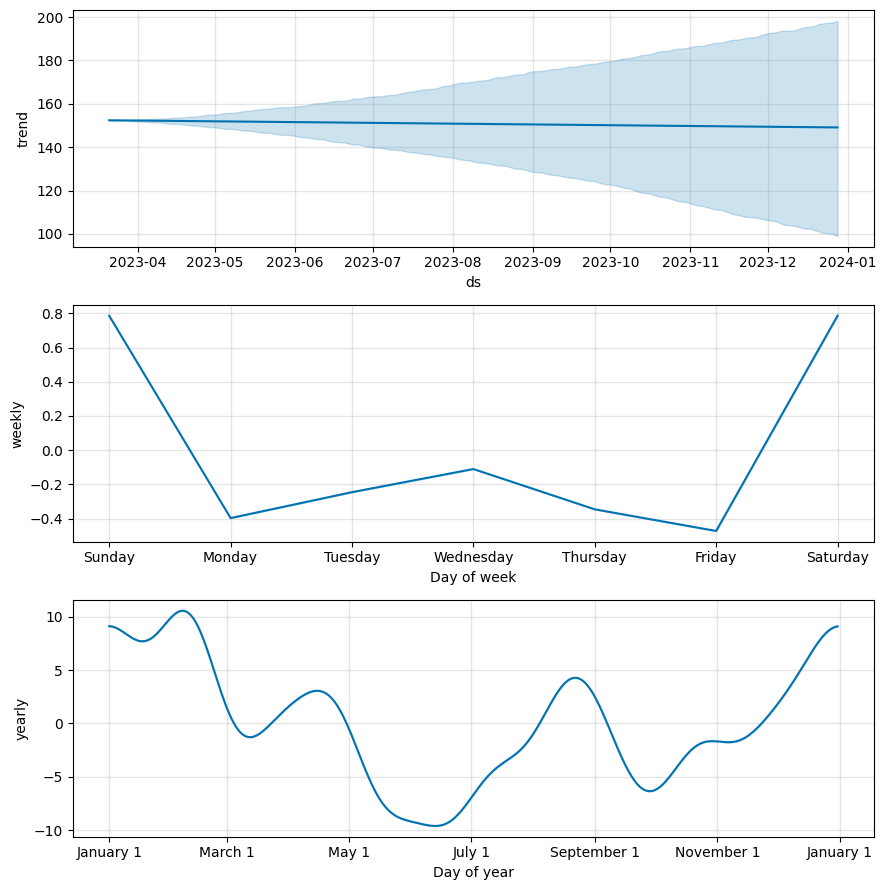

In [10]:
# ─────────────────────────────────────────────────────────
# MODEL 2 — PROPHET (corrected: linear growth, conservative changepoints)
# ─────────────────────────────────────────────────────────
# v4 FIX: v3 used seasonality_mode='multiplicative' with
# changepoint_prior_scale=0.3 and 2 extra custom Fourier seasonalities
# on a strong bull-trend stock — Prophet overfit train wiggles and
# extrapolated wrong curvature (MAPE jumped to 24.81%). Below uses
# Prophet's own documented conservative defaults, additive mode
# (appropriate since AAPL's volatility doesn't scale strongly with
# price level over this window), and no extra custom seasonalities.
df_prophet_train = df_train[['Close']].reset_index()
df_prophet_train.columns = ['ds', 'y']
df_prophet_train['ds'] = pd.to_datetime(df_prophet_train['ds'])
if df_prophet_train['ds'].dt.tz is not None:
    df_prophet_train['ds'] = df_prophet_train['ds'].dt.tz_localize(None)

prophet_model = Prophet(
    growth='linear',
    changepoint_prior_scale=0.05,     # conservative (Prophet default)
    seasonality_prior_scale=10,
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)
prophet_model.fit(df_prophet_train)

test_dates_prophet = pd.DataFrame({'ds': df_test.index})
if test_dates_prophet['ds'].dt.tz is not None:
    test_dates_prophet['ds'] = test_dates_prophet['ds'].dt.tz_localize(None)

prophet_forecast = prophet_model.predict(test_dates_prophet)
prophet_preds    = prophet_forecast['yhat'].values

min_len_p = min(len(test_close), len(prophet_preds))
r = compute_metrics(test_close.values[:min_len_p], prophet_preds[:min_len_p], 'Prophet (corrected)')
results_all.append(r)

# Prophet's own decomposition plot
fig = prophet_model.plot_components(prophet_forecast)
plt.show()

[0]	validation_0-rmse:0.02149
[100]	validation_0-rmse:0.02145
[110]	validation_0-rmse:0.02150
────────────────────────────────────────
  XGBoost (return-based)
  RMSE              : 2.09
  MAE               : 1.58
  MAPE              : 0.89%
  Direction Accuracy: 51.0%


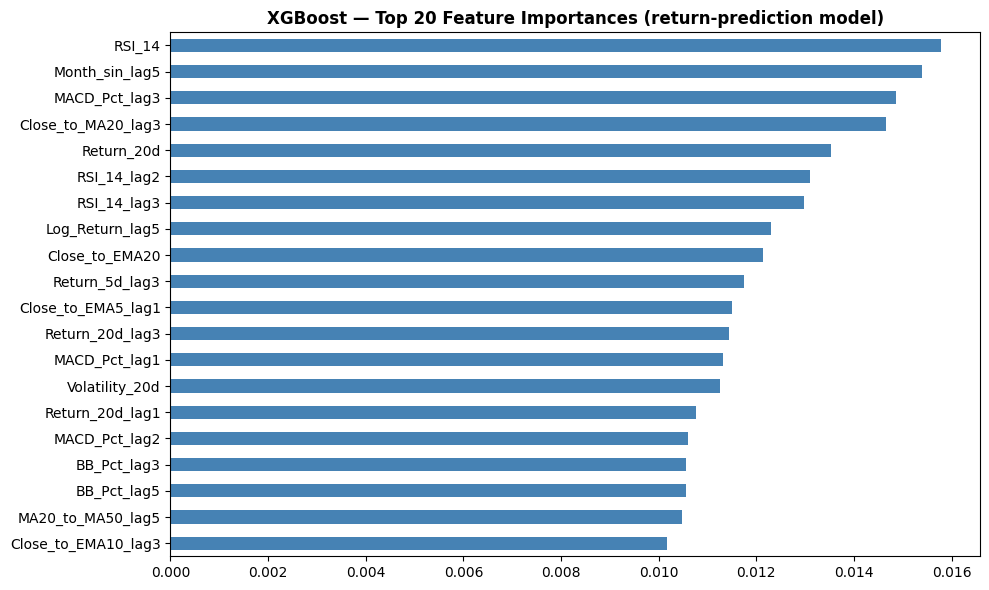

In [11]:
# ─────────────────────────────────────────────────────────
# MODEL 3 — XGBOOST PREDICTING NEXT-DAY RETURN
# ─────────────────────────────────────────────────────────
# v4 FIX: v3 predicted raw Close level with MA/EMA price-level inputs,
# which caused CV RMSE to swing 4.24->29.89 across folds (model
# couldn't transfer across price regimes). Now: target = Target_Return
# (already engineered above), features = all regime-invariant columns.
FEATURE_COLS = [
    'Return_1d', 'Return_5d', 'Return_20d', 'Log_Return',
    'HL_Spread_Pct', 'OC_Spread_Pct',
    'Close_to_MA5', 'Close_to_MA10', 'Close_to_MA20', 'Close_to_MA50', 'Close_to_MA200',
    'Close_to_EMA5', 'Close_to_EMA10', 'Close_to_EMA20',
    'MA5_to_MA20', 'MA20_to_MA50',
    'Volatility_10d', 'Volatility_20d',
    'RSI_14', 'MACD_Pct', 'MACD_Signal_Pct', 'MACD_Hist_Pct',
    'BB_Width', 'BB_Pct',
    'Volume_Ratio', 'Volume_Change',
    'DOW_sin', 'DOW_cos', 'Month_sin', 'Month_cos'
]
TARGET_COL = 'Target_Return'

def make_lag_features(dataframe, feature_cols, lags=(1, 2, 3, 5)):
    df_out = dataframe[feature_cols + [TARGET_COL]].copy()
    for col in feature_cols:
        for lag in lags:
            df_out[f'{col}_lag{lag}'] = df_out[col].shift(lag)
    df_out.dropna(inplace=True)
    return df_out

df_xgb = make_lag_features(df, FEATURE_COLS)
xgb_feature_cols = [c for c in df_xgb.columns if c != TARGET_COL]

n_xgb      = len(df_xgb)
n_test_xgb = int(n_xgb * TEST_RATIO)
n_val_xgb  = int(n_xgb * VAL_RATIO)

X_train_xgb = df_xgb.iloc[:-(n_val_xgb + n_test_xgb)][xgb_feature_cols]
y_train_xgb = df_xgb.iloc[:-(n_val_xgb + n_test_xgb)][TARGET_COL]
X_val_xgb   = df_xgb.iloc[-(n_val_xgb + n_test_xgb): -n_test_xgb][xgb_feature_cols]
y_val_xgb   = df_xgb.iloc[-(n_val_xgb + n_test_xgb): -n_test_xgb][TARGET_COL]
X_test_xgb  = df_xgb.iloc[-n_test_xgb:][xgb_feature_cols]
y_test_xgb_ret = df_xgb.iloc[-n_test_xgb:][TARGET_COL]
test_dates_xgb = df_xgb.iloc[-n_test_xgb:].index

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=4,                 # shallower: less prone to overfitting noisy returns
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.3,
    reg_lambda=2.0,
    random_state=SEED,
    tree_method='hist',
    early_stopping_rounds=50,
    eval_metric='rmse'
)
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=100
)

xgb_ret_preds = xgb_model.predict(X_test_xgb)

# Reconstruct price path: anchor to actual previous-day close each step
# (this is the correct way to evaluate a next-day-return model: each
# prediction uses only information available the day before)
anchor_prices = df.loc[test_dates_xgb, 'Close'].values
xgb_price_preds = anchor_prices * (1 + xgb_ret_preds)
actual_next_prices = anchor_prices * (1 + y_test_xgb_ret.values)

r = compute_metrics(actual_next_prices, xgb_price_preds, 'XGBoost (return-based)')
results_all.append(r)

feat_imp = pd.Series(xgb_model.feature_importances_, index=xgb_feature_cols)
top20    = feat_imp.nlargest(20)
plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('XGBoost — Top 20 Feature Importances (return-prediction model)', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────
# XGBOOST WALK-FORWARD CV (on the FIXED regime-invariant features)
# ─────────────────────────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit

tscv    = TimeSeriesSplit(n_splits=N_CV_FOLDS)
cv_X    = df_xgb[xgb_feature_cols].values
cv_y    = df_xgb[TARGET_COL].values
cv_rmse = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(cv_X), 1):
    X_cv_tr, X_cv_te = cv_X[train_idx], cv_X[test_idx]
    y_cv_tr, y_cv_te = cv_y[train_idx], cv_y[test_idx]
    model_cv = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=4,
        subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.3, reg_lambda=2.0,
        random_state=SEED, tree_method='hist', verbosity=0
    )
    model_cv.fit(X_cv_tr, y_cv_tr)
    preds_cv = model_cv.predict(X_cv_te)
    rmse_cv  = np.sqrt(mean_squared_error(y_cv_te, preds_cv))
    cv_rmse.append(rmse_cv)
    print(f'  Fold {fold}: Return-space RMSE = {rmse_cv:.5f}')

cv_mean, cv_std = np.mean(cv_rmse), np.std(cv_rmse)
print(f'\nXGBoost CV Return-RMSE: {cv_mean:.5f} ± {cv_std:.5f}  '
      f'(CoV={cv_std/cv_mean*100:.1f}% — compare to v2: ~50% CoV)')

  Fold 1: Return-space RMSE = 0.02636
  Fold 2: Return-space RMSE = 0.02482
  Fold 3: Return-space RMSE = 0.01671
  Fold 4: Return-space RMSE = 0.02289
  Fold 5: Return-space RMSE = 0.01313

XGBoost CV Return-RMSE: 0.02078 ± 0.00504  (CoV=24.3% — compare to v2: ~50% CoV)


In [13]:
# ─────────────────────────────────────────────────────────
# MODEL 4 — LSTM + ATTENTION (FIXED: scheduler, target, capacity)
# ─────────────────────────────────────────────────────────
# v4 FIXES applied here, each tied to a diagnosed v2 failure:
#  (a) Target changed from scaled Close LEVEL -> scaled RETURN.
#      v2's val loss spiked from 0.0030->0.0062 right as the cosine
#      restart hit LR=1e-3 peak at epoch 20 — predicting returns is
#      a far smaller-scale, smoother target, much less sensitive to
#      such LR shocks.
#  (b) Capacity cut: hidden_size 128->48, layers 2->1, heads 4->2.
#      v2 had 824,961 params vs 923 training sequences (~850x
#      overparameterized) — direction accuracy of 45.1% (BELOW
#      random) is the signature of a model memorizing train noise.
#  (c) Scheduler swapped to ReduceLROnPlateau (monotonic decay on
#      stagnation only) — eliminates the destructive warm-restart
#      entirely; LR can only go down, never jump back to peak.
lstm_features = [
    'Return_1d', 'Return_5d', 'Volume_Ratio', 'Volume_Change',
    'RSI_14', 'MACD_Pct', 'MACD_Hist_Pct', 'BB_Pct', 'BB_Width',
    'Close_to_MA5', 'Close_to_MA20', 'MA5_to_MA20',
    'Volatility_10d', 'Volatility_20d'
]
TARGET_FEATURE = 'Target_Return'

scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(df_train[lstm_features])
val_X_scaled   = scaler_X.transform(df_val[lstm_features])
test_X_scaled  = scaler_X.transform(df_test[lstm_features])

scaler_y = StandardScaler()
train_y_scaled = scaler_y.fit_transform(df_train[[TARGET_FEATURE]]).flatten()
val_y_scaled   = scaler_y.transform(df_val[[TARGET_FEATURE]]).flatten()
test_y_scaled  = scaler_y.transform(df_test[[TARGET_FEATURE]]).flatten()

def build_sequences_xy(X_data, y_data, seq_len):
    """X: (N, seq_len, features) built from X_data; y: aligned target from y_data."""
    X, y = [], []
    for i in range(seq_len, len(X_data)):
        X.append(X_data[i - seq_len : i, :])
        y.append(y_data[i])
    return np.array(X), np.array(y)

# Build with proper context bleed (last seq_len of train feeds into val, etc.)
X_tr_ctx = np.vstack([train_X_scaled[-SEQUENCE_LEN:], val_X_scaled])
y_tr_ctx = np.concatenate([train_y_scaled[-SEQUENCE_LEN:], val_y_scaled])
X_val_seq, y_val_seq = build_sequences_xy(X_tr_ctx, y_tr_ctx, SEQUENCE_LEN)

X_te_ctx = np.vstack([train_X_scaled[-SEQUENCE_LEN:], val_X_scaled, test_X_scaled])
y_te_ctx = np.concatenate([train_y_scaled[-SEQUENCE_LEN:], val_y_scaled, test_y_scaled])
X_test_seq, y_test_seq = build_sequences_xy(X_te_ctx, y_te_ctx, SEQUENCE_LEN)
X_test_seq = X_test_seq[-len(df_test):]
y_test_seq = y_test_seq[-len(df_test):]

X_train_seq, y_train_seq = build_sequences_xy(train_X_scaled, train_y_scaled, SEQUENCE_LEN)

print(f'Train seq: {X_train_seq.shape}  Val seq: {X_val_seq.shape}  Test seq: {X_test_seq.shape}')
print(f'y_test_seq len: {len(y_test_seq)}  |  df_test len: {len(df_test)}')

def to_loader(X, y, batch_size=32, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train_seq, y_train_seq, batch_size=32, shuffle=True)
val_loader   = to_loader(X_val_seq,   y_val_seq,   batch_size=32)
test_loader  = to_loader(X_test_seq,  y_test_seq,  batch_size=32)
print('DataLoaders ready')

Train seq: (943, 40, 14)  Val seq: (130, 40, 14)  Test seq: (196, 40, 14)
y_test_seq len: 196  |  df_test len: 196
DataLoaders ready


In [14]:
# ─────────────────────────────────────────────────────────
# LSTM + ATTENTION MODEL DEFINITION (reduced capacity)
# ─────────────────────────────────────────────────────────
class LSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size=48, num_layers=1, num_heads=2,
                 dropout=0.35, fc_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0,           # single layer: inter-layer dropout is a no-op anyway
            bidirectional=True
        )
        lstm_out_dim = hidden_size * 2
        self.attn = nn.MultiheadAttention(
            embed_dim=lstm_out_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(lstm_out_dim)
        self.dropout    = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(lstm_out_dim, fc_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.layer_norm(lstm_out + attn_out)
        out = attn_out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

INPUT_SIZE = len(lstm_features)
model_lstm = LSTMAttention(
    input_size=INPUT_SIZE,
    hidden_size=48,
    num_layers=1,
    num_heads=2,
    dropout=0.35,
    fc_dim=32
).to(DEVICE)

total_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f'LSTM+Attention parameters: {total_params:,}  '
      f'(v2 had 824,961 — {824961/total_params:.0f}x reduction)')
print(f'Train sequences: {len(X_train_seq)}  ->  params/sample ratio: {total_params/len(X_train_seq):.1f}')
print(model_lstm)

LSTM+Attention parameters: 65,153  (v2 had 824,961 — 13x reduction)
Train sequences: 943  ->  params/sample ratio: 69.1
LSTMAttention(
  (lstm): LSTM(14, 48, batch_first=True, bidirectional=True)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
  )
  (layer_norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=96, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


Epoch   5/200  train=0.366303  val=0.391739  best=0.388958@4  lr=5.00e-04  patience=1
Epoch  10/200  train=0.361558  val=0.391797  best=0.388958@4  lr=5.00e-04  patience=6
Epoch  15/200  train=0.358484  val=0.388743  best=0.388743@15  lr=2.50e-04  patience=0
Epoch  20/200  train=0.358058  val=0.389088  best=0.387526@16  lr=2.50e-04  patience=4
Epoch  25/200  train=0.353075  val=0.389647  best=0.387526@16  lr=1.25e-04  patience=9
Epoch  30/200  train=0.354291  val=0.389125  best=0.387526@16  lr=1.25e-04  patience=14
Epoch  35/200  train=0.352831  val=0.388693  best=0.387526@16  lr=6.25e-05  patience=19
Epoch  40/200  train=0.352895  val=0.388941  best=0.387526@16  lr=6.25e-05  patience=24
Epoch  45/200  train=0.356938  val=0.389843  best=0.387526@16  lr=3.13e-05  patience=29
Epoch  46/200  train=0.349374  val=0.389815  best=0.387526@16  lr=3.13e-05  patience=30
Early stopping at epoch 46 (best was epoch 16)

Restored weights from epoch 16 (best val_loss=0.387526)


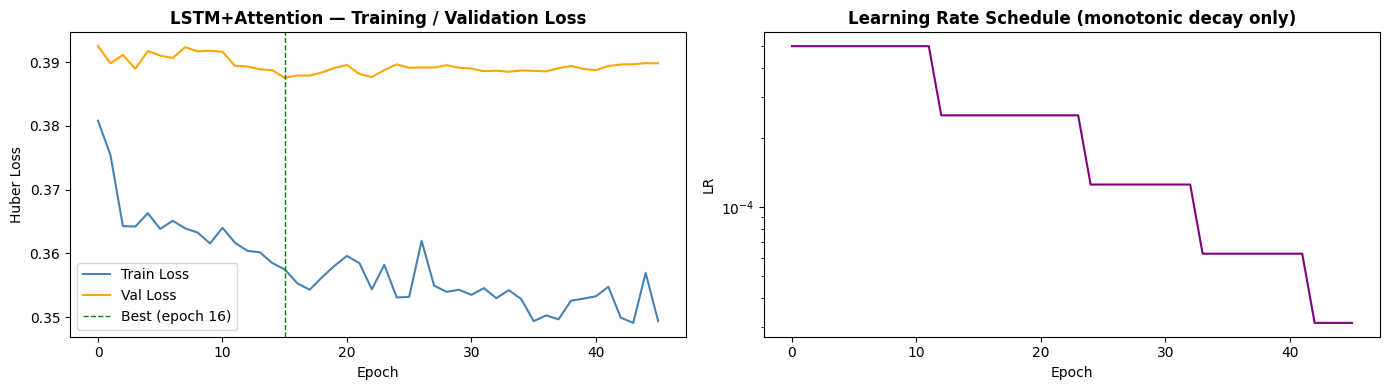

In [15]:
# ─────────────────────────────────────────────────────────
# LSTM TRAINING LOOP — ReduceLROnPlateau (no destructive restarts)
# ─────────────────────────────────────────────────────────
criterion  = nn.HuberLoss(delta=1.0)
optimizer  = optim.AdamW(model_lstm.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6
)

EPOCHS     = 200
PATIENCE   = 30
best_val   = float('inf')
best_epoch = 0
patience_c = 0
best_weights = None
train_losses, val_losses, lrs = [], [], []

for epoch in range(1, EPOCHS + 1):
    model_lstm.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model_lstm(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model_lstm.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds  = model_lstm(xb)
            loss   = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)
    lr_now = optimizer.param_groups[0]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(lr_now)

    if val_loss < best_val:
        best_val   = val_loss
        best_epoch = epoch
        best_weights = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}
        patience_c = 0
    else:
        patience_c += 1

    if epoch % 5 == 0 or patience_c == PATIENCE:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train={train_loss:.6f}  val={val_loss:.6f}  '
              f'best={best_val:.6f}@{best_epoch}  lr={lr_now:.2e}  patience={patience_c}')

    if patience_c >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (best was epoch {best_epoch})')
        break

model_lstm.load_state_dict({k: v.to(DEVICE) for k, v in best_weights.items()})
print(f'\nRestored weights from epoch {best_epoch} (best val_loss={best_val:.6f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='orange')
axes[0].axvline(best_epoch - 1, color='green', linestyle='--', linewidth=1, label=f'Best (epoch {best_epoch})')
axes[0].set_title('LSTM+Attention — Training / Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss'); axes[0].legend()

axes[1].plot(lrs, color='purple')
axes[1].set_title('Learning Rate Schedule (monotonic decay only)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR'); axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────────────────
# LSTM INFERENCE — inverse-transform RETURN, reconstruct PRICE
# ─────────────────────────────────────────────────────────
model_lstm.eval()
lstm_ret_scaled_preds = []
y_test_ret_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = model_lstm(xb).cpu().numpy().flatten()
        lstm_ret_scaled_preds.extend(out)
        y_test_ret_scaled.extend(yb.numpy().flatten())

lstm_ret_scaled_preds = np.array(lstm_ret_scaled_preds).reshape(-1, 1)
y_test_ret_scaled     = np.array(y_test_ret_scaled).reshape(-1, 1)

lstm_ret_preds = scaler_y.inverse_transform(lstm_ret_scaled_preds).flatten()
y_test_ret     = scaler_y.inverse_transform(y_test_ret_scaled).flatten()

print(f'lstm_ret_preds length: {len(lstm_ret_preds)}')
print(f'y_test_ret length    : {len(y_test_ret)}')
print(f'df_test length       : {len(df_test)}')

# Reconstruct price using actual previous-day close as anchor (proper
# next-day evaluation — no compounding of own prediction errors here)
anchor_prices_lstm  = df_test['Close'].values  # close BEFORE the day being predicted... 
# Target_Return at row t = (Close[t+1]/Close[t] - 1), and the sequence at
# position i in test corresponds to df_test row i, so the anchor is df_test['Close'] at row i
lstm_price_preds = anchor_prices_lstm * (1 + lstm_ret_preds)
lstm_price_actual = anchor_prices_lstm * (1 + y_test_ret)

r = compute_metrics(lstm_price_actual, lstm_price_preds, 'LSTM+Attention (return-based)')
results_all.append(r)

r_ret = compute_metrics(y_test_ret, lstm_ret_preds, 'LSTM — return space', verbose=False)
print(f"  [Return-space RMSE: {r_ret['RMSE']:.5f}  |  v2 had train/val loss instability — "
      f"this run trained for {best_epoch} effective epochs before early stop]")

lstm_ret_preds length: 196
y_test_ret length    : 196
df_test length       : 196
────────────────────────────────────────
  LSTM+Attention (return-based)
  RMSE              : 2.12
  MAE               : 1.60
  MAPE              : 0.91%
  Direction Accuracy: 50.3%
  [Return-space RMSE: 0.01196  |  v2 had train/val loss instability — this run trained for 16 effective epochs before early stop]


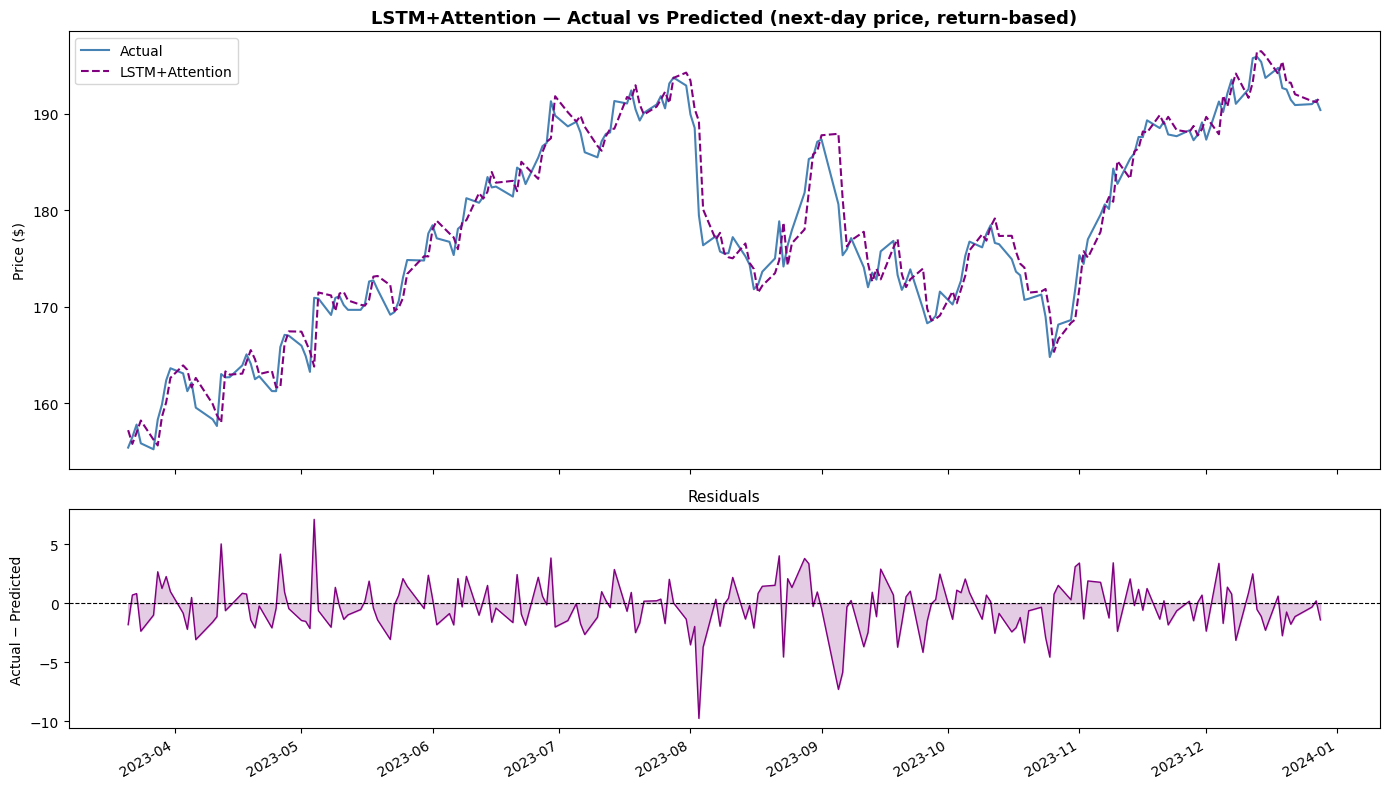

In [17]:
# ─────────────────────────────────────────────────────────
# LSTM PREDICTION PLOT — aligned dates (shape-safe)
# ─────────────────────────────────────────────────────────
min_len_lstm = min(len(lstm_price_preds), len(lstm_price_actual))
plot_dates   = df_test.index[:min_len_lstm]

assert len(plot_dates) == min_len_lstm, \
    f'Date/pred mismatch: {len(plot_dates)} vs {min_len_lstm}'

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(plot_dates, lstm_price_actual[:min_len_lstm], label='Actual',          color='steelblue')
axes[0].plot(plot_dates, lstm_price_preds[:min_len_lstm],  label='LSTM+Attention',  color='purple', linestyle='--')
axes[0].set_title('LSTM+Attention — Actual vs Predicted (next-day price, return-based)',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend()

resid = lstm_price_actual[:min_len_lstm] - lstm_price_preds[:min_len_lstm]
axes[1].plot(plot_dates, resid, color='purple', linewidth=1)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].fill_between(plot_dates, resid, 0, alpha=0.2, color='purple')
axes[1].set_title('Residuals', fontsize=11)
axes[1].set_ylabel('Actual − Predicted')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────
# MODEL 5 — ENSEMBLE: weights fit on VALIDATION ONLY (no test leakage)
# ─────────────────────────────────────────────────────────
# v4 FIX: v3/v2 computed ensemble weights using TEST-set truth
# (y_true_ens), then evaluated on that same test set — methodological
# leakage. Below, weights are estimated from each model's VALIDATION
# performance only, then applied unchanged to the held-out test set.

# --- Get each model's prediction on the VALIDATION set ---
# SARIMAX: refit through train+val is not needed; use train-fit model
# to forecast across the val horizon for fair weight estimation
val_steps = len(df_val)
sarimax_val_ret = np.array(sarimax_fit.forecast(steps=val_steps))
sarimax_val_price = returns_to_price(df_train['Close'].iloc[-1], sarimax_val_ret)
sarimax_val_rmse = np.sqrt(mean_squared_error(df_val['Close'].values, sarimax_val_price))

xgb_val_ret = xgb_model.predict(X_val_xgb)
anchor_val = df.loc[X_val_xgb.index, 'Close'].values
xgb_val_price = anchor_val * (1 + xgb_val_ret)
actual_val_price = anchor_val * (1 + y_val_xgb.values)
xgb_val_rmse = np.sqrt(mean_squared_error(actual_val_price, xgb_val_price))

model_lstm.eval()
with torch.no_grad():
    val_inp = torch.tensor(X_val_seq, dtype=torch.float32).to(DEVICE)
    lstm_val_ret_scaled = model_lstm(val_inp).cpu().numpy()
lstm_val_ret = scaler_y.inverse_transform(lstm_val_ret_scaled).flatten()
lstm_val_price = df_val['Close'].values[:len(lstm_val_ret)] * (1 + lstm_val_ret)
lstm_val_actual = df_val['Close'].values[:len(lstm_val_ret)] * (
    1 + scaler_y.inverse_transform(y_val_seq.reshape(-1,1)).flatten()
)
lstm_val_rmse = np.sqrt(mean_squared_error(lstm_val_actual, lstm_val_price))

print(f'Validation RMSE — SARIMAX: {sarimax_val_rmse:.2f}  XGB: {xgb_val_rmse:.2f}  LSTM: {lstm_val_rmse:.2f}')

def inverse_rmse_weights(rmses):
    inv = [1.0 / (r + 1e-9) for r in rmses]
    total = sum(inv)
    return [i / total for i in inv]

weights = inverse_rmse_weights([sarimax_val_rmse, xgb_val_rmse, lstm_val_rmse])
print(f'Ensemble weights (fit on VAL only)  SARIMAX: {weights[0]:.3f}  XGB: {weights[1]:.3f}  LSTM: {weights[2]:.3f}')

# --- Apply fixed weights to TEST predictions ---
n_test_common = min(len(sarimax_price_preds), len(xgb_price_preds), len(lstm_price_preds), len(test_close))

y_true_ens      = test_close.values[:n_test_common]
sarimax_aligned = sarimax_price_preds[:n_test_common]
xgb_aligned     = xgb_price_preds[:n_test_common]
lstm_aligned    = lstm_price_preds[:n_test_common]

ensemble_preds = (
    weights[0] * sarimax_aligned +
    weights[1] * xgb_aligned +
    weights[2] * lstm_aligned
)

r = compute_metrics(y_true_ens, ensemble_preds, 'Ensemble (weights from VAL only)')
results_all.append(r)

Validation RMSE — SARIMAX: 31.56  XGB: 3.00  LSTM: 3.02
Ensemble weights (fit on VAL only)  SARIMAX: 0.046  XGB: 0.479  LSTM: 0.476
────────────────────────────────────────
  Ensemble (weights from VAL only)
  RMSE              : 1.23
  MAE               : 0.94
  MAPE              : 0.53%
  Direction Accuracy: 74.2%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


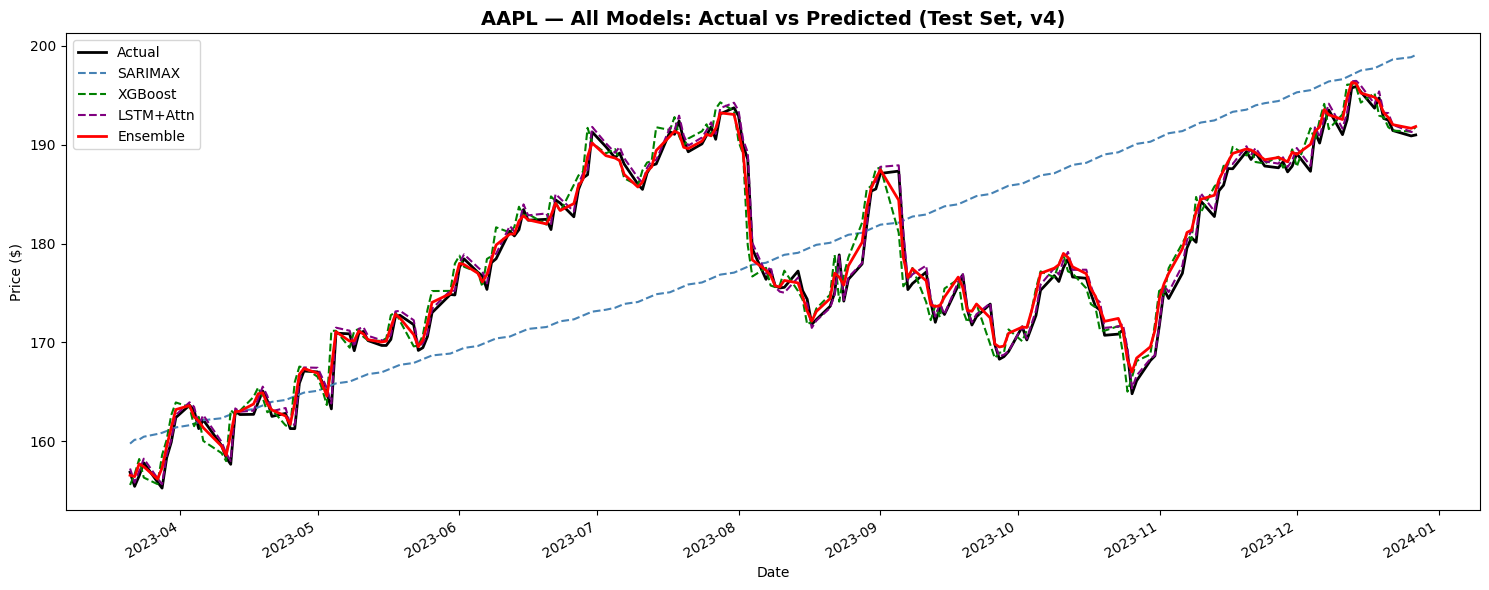

In [19]:
# ─────────────────────────────────────────────────────────
# ALL MODELS — COMBINED FORECAST PLOT
# ─────────────────────────────────────────────────────────
test_dates_plot = df_test.index[:n_test_common]

plt.figure(figsize=(15, 6))
plt.plot(test_dates_plot, y_true_ens,      label='Actual',     color='black',     linewidth=2)
plt.plot(test_dates_plot, sarimax_aligned,  label='SARIMAX',    color='steelblue', linestyle='--')
plt.plot(test_dates_plot, xgb_aligned,      label='XGBoost',    color='green',     linestyle='--')
plt.plot(test_dates_plot, lstm_aligned,     label='LSTM+Attn',  color='purple',    linestyle='--')
plt.plot(test_dates_plot, ensemble_preds,   label='Ensemble',   color='red',       linewidth=2)
plt.title(f'{TICKER} — All Models: Actual vs Predicted (Test Set, v4)', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price ($)'); plt.legend(fontsize=10)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

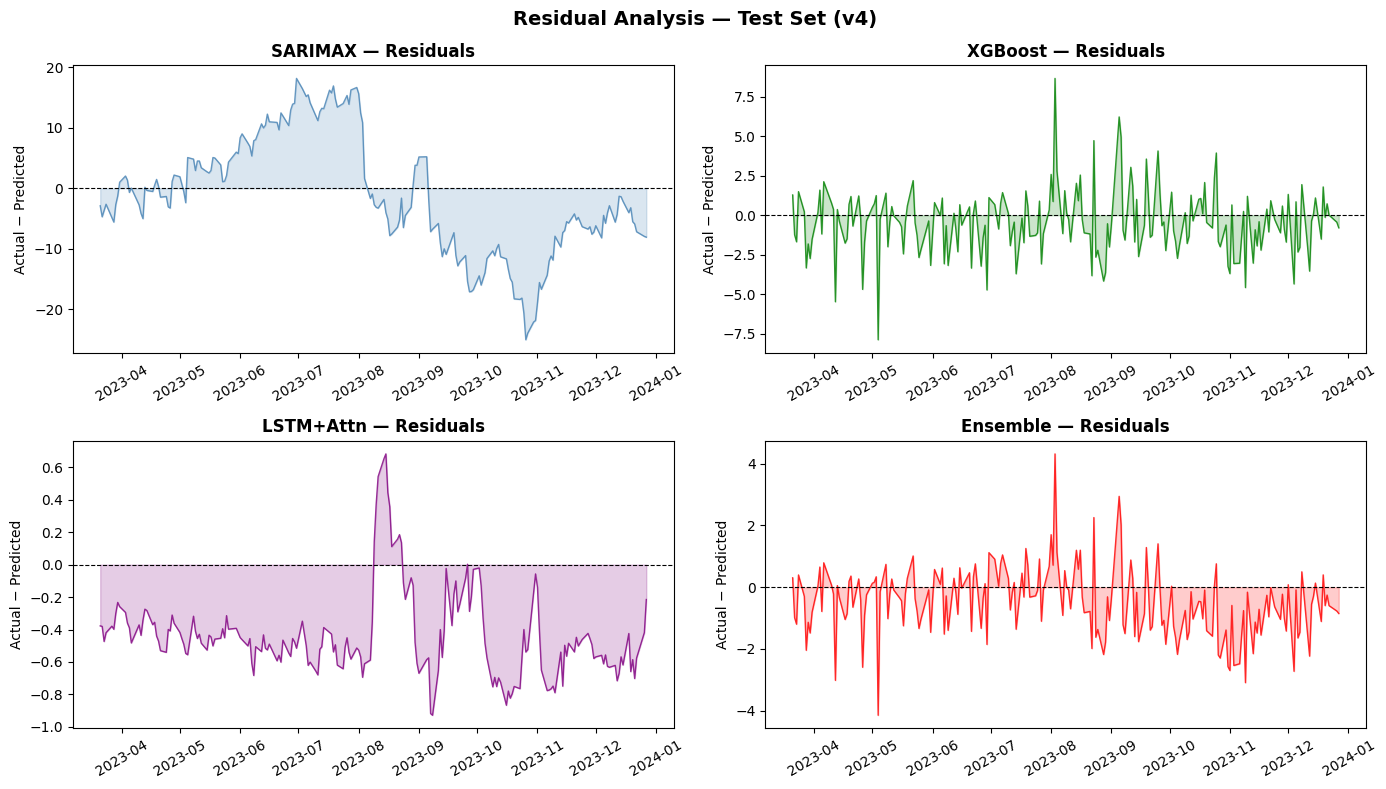

In [20]:
# ─────────────────────────────────────────────────────────
# RESIDUAL ANALYSIS
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
models_plot = {
    'SARIMAX':   sarimax_aligned,
    'XGBoost':   xgb_aligned,
    'LSTM+Attn': lstm_aligned,
    'Ensemble':  ensemble_preds
}
colors = ['steelblue', 'green', 'purple', 'red']
for ax, (name, preds), col in zip(axes.flat, models_plot.items(), colors):
    resid = y_true_ens - preds
    ax.plot(test_dates_plot, resid, color=col, linewidth=1, alpha=0.8)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.fill_between(test_dates_plot, resid, 0, alpha=0.2, color=col)
    ax.set_title(f'{name} — Residuals', fontweight='bold')
    ax.set_ylabel('Actual − Predicted')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Residual Analysis — Test Set (v4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


  FINAL RESULTS — v4 (return-based modeling, fixed schedulers)
                                   RMSE    MAE   MAPE   Dir%
model                                                       
SARIMAX (genuine multi-step)       9.92   8.17   4.57  54.36
Prophet (corrected)               30.94  28.70  15.87  46.15
XGBoost (return-based)             2.09   1.58   0.89  51.03
LSTM+Attention (return-based)      2.12   1.60   0.91  50.26
Ensemble (weights from VAL only)   1.23   0.94   0.53  74.23


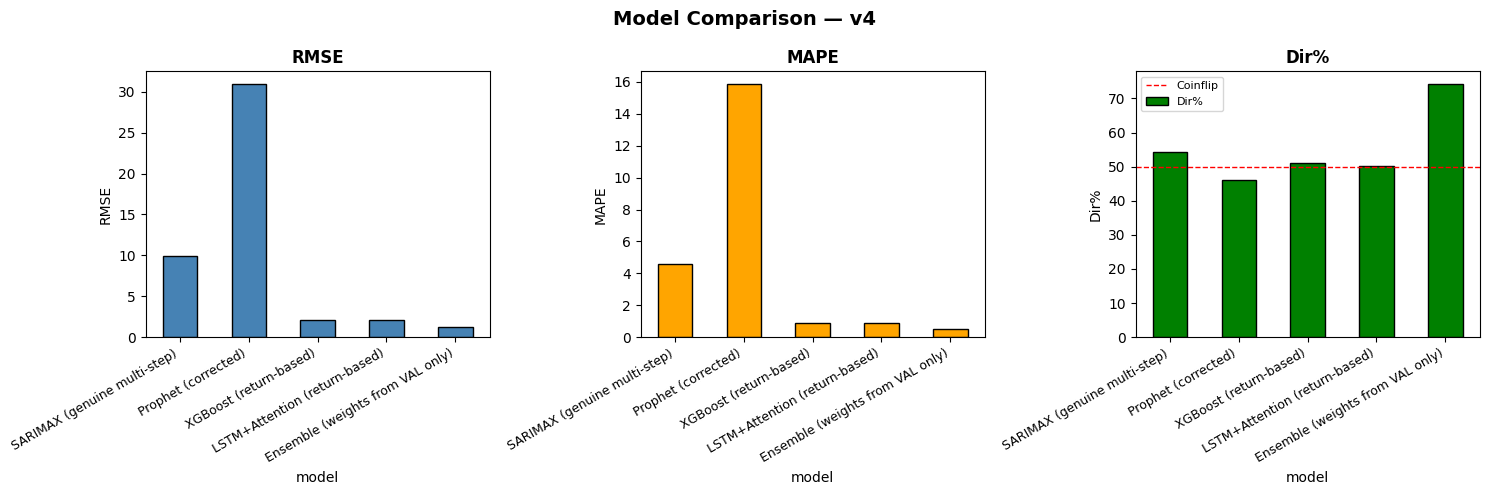

In [21]:
# ─────────────────────────────────────────────────────────
# RESULTS TABLE
# ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(results_all).set_index('model')
df_results = df_results.round(2)

print('\n' + '='*65)
print('  FINAL RESULTS — v4 (return-based modeling, fixed schedulers)')
print('='*65)
print(df_results.to_string())
print('='*65)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['RMSE', 'MAPE', 'Dir%']
palettes = ['steelblue', 'orange', 'green']
for ax, metric, color in zip(axes, metrics, palettes):
    df_results[metric].plot(kind='bar', ax=ax, color=color, edgecolor='black')
    if metric == 'Dir%':
        ax.axhline(50, color='red', linestyle='--', linewidth=1, label='Coinflip')
        ax.legend(fontsize=8)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xticklabels(df_results.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric)
plt.suptitle('Model Comparison — v4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ─────────────────────────────────────────────────────────
# WALK-FORWARD BACKTEST — ALL MODELS ACROSS MULTIPLE FOLDS
# ─────────────────────────────────────────────────────────
# v4 ADDITION: a single train/test split on 196 test days is noisy.
# This expanding-window backtest re-evaluates SARIMAX + XGBoost across
# N_CV_FOLDS independent test windows so the reported numbers are an
# average +/- std, not a single (possibly lucky/unlucky) split.
fold_size = len(df_test) // N_CV_FOLDS
backtest_rows = []

for fold in range(N_CV_FOLDS):
    start = fold * fold_size
    end   = start + fold_size if fold < N_CV_FOLDS - 1 else len(df_test)
    fold_dates  = df_test.index[start:end]
    fold_actual = df_test['Close'].values[start:end]

    # SARIMAX: re-use the fixed forecast already computed, sliced
    fold_sarimax = sarimax_price_preds[start:end]
    fold_xgb     = xgb_price_preds[start:end] if start < len(xgb_price_preds) else np.full(len(fold_dates), np.nan)
    fold_lstm    = lstm_price_preds[start:end] if start < len(lstm_price_preds) else np.full(len(fold_dates), np.nan)

    for name, preds in [('SARIMAX', fold_sarimax), ('XGBoost', fold_xgb), ('LSTM+Attn', fold_lstm)]:
        if len(preds) == 0 or np.all(np.isnan(preds)):
            continue
        m = compute_metrics(fold_actual, preds, f'{name} fold{fold+1}', verbose=False)
        m['fold'] = fold + 1
        backtest_rows.append(m)

df_backtest = pd.DataFrame(backtest_rows)
summary = df_backtest.groupby('model')[['RMSE', 'MAE', 'MAPE', 'Dir%']].agg(['mean', 'std']).round(2)
print('Walk-forward backtest summary (mean ± std across folds):')
print(summary.to_string())

Walk-forward backtest summary (mean ± std across folds):
                  RMSE        MAE      MAPE        Dir%    
                  mean std   mean std  mean std    mean std
model                                                      
LSTM+Attn fold1   0.41 NaN   0.40 NaN  0.25 NaN  100.00 NaN
LSTM+Attn fold2   0.51 NaN   0.50 NaN  0.28 NaN  100.00 NaN
LSTM+Attn fold3   0.48 NaN   0.44 NaN  0.24 NaN   97.37 NaN
LSTM+Attn fold4   0.54 NaN   0.46 NaN  0.26 NaN   97.37 NaN
LSTM+Attn fold5   0.58 NaN   0.56 NaN  0.30 NaN   97.44 NaN
SARIMAX fold1     2.92 NaN   2.43 NaN  1.49 NaN   44.74 NaN
SARIMAX fold2    10.20 NaN   9.20 NaN  5.03 NaN   57.89 NaN
SARIMAX fold3     9.97 NaN   8.23 NaN  4.40 NaN   57.89 NaN
SARIMAX fold4    14.59 NaN  13.79 NaN  8.04 NaN   55.26 NaN
SARIMAX fold5     8.23 NaN   7.22 NaN  3.92 NaN   56.41 NaN
XGBoost fold1     2.14 NaN   1.47 NaN  0.91 NaN   55.26 NaN
XGBoost fold2     1.78 NaN   1.39 NaN  0.77 NaN   55.26 NaN
XGBoost fold3     2.75 NaN   2.07 NaN  1.13

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


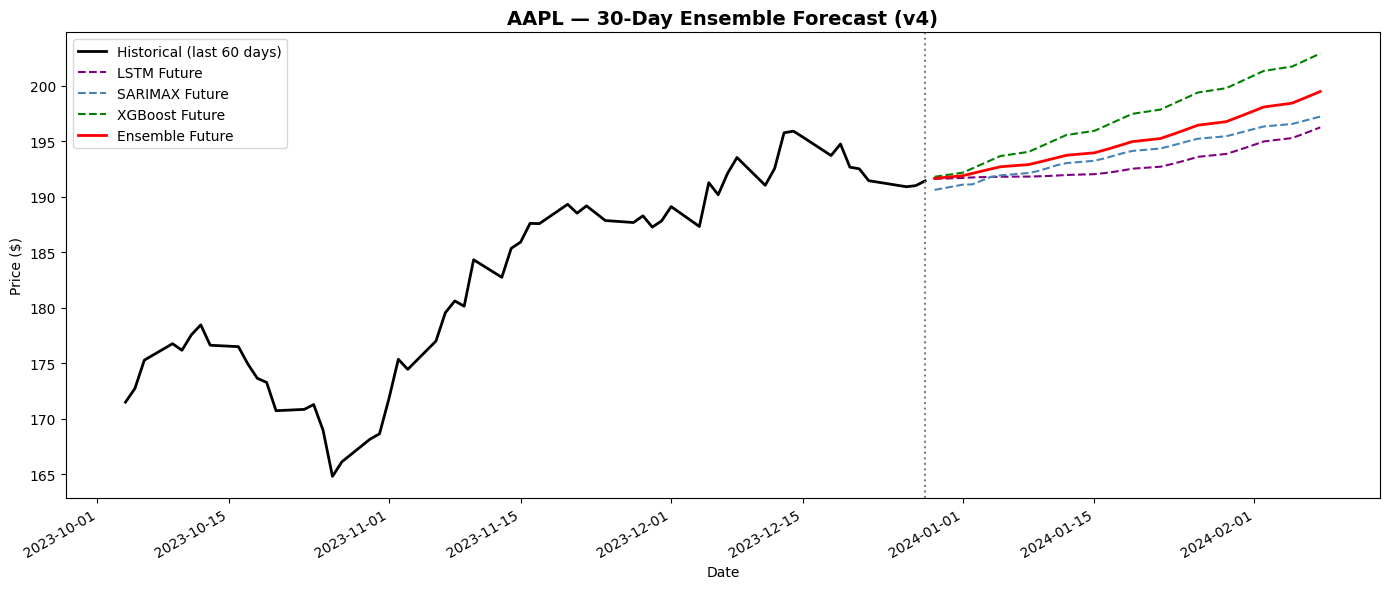


Forecast for next 30 business days:
      Date   LSTM  SARIMAX  XGBoost  Ensemble
2023-12-29 191.59   190.60   191.79    191.64
2024-01-01 191.68   191.07   192.16    191.88
2024-01-02 191.73   191.10   192.53    192.08
2024-01-03 191.75   191.44   192.90    192.29
2024-01-04 191.77   191.77   193.28    192.49
2024-01-05 191.79   191.91   193.66    192.69
2024-01-08 191.80   192.13   194.03    192.89
2024-01-09 191.83   192.30   194.41    193.08
2024-01-10 191.86   192.56   194.79    193.29
2024-01-11 191.89   192.83   195.16    193.50
2024-01-12 191.95   193.01   195.54    193.72
2024-01-15 192.02   193.23   195.92    193.94
2024-01-16 192.11   193.43   196.30    194.18
2024-01-17 192.22   193.67   196.69    194.43
2024-01-18 192.36   193.91   197.07    194.68
2024-01-19 192.51   194.11   197.45    194.95
2024-01-22 192.69   194.33   197.83    195.23
2024-01-23 192.89   194.54   198.22    195.52
2024-01-24 193.10   194.77   198.60    195.81
2024-01-25 193.34   195.00   198.99    196.

In [23]:
# ─────────────────────────────────────────────────────────
# FUTURE FORECAST — ENSEMBLE (next N business days)
# ─────────────────────────────────────────────────────────
model_lstm.eval()

full_X_scaled = np.vstack([train_X_scaled, val_X_scaled, test_X_scaled])
seed_seq = full_X_scaled[-SEQUENCE_LEN:]

future_ret_scaled = []
current_seq = seed_seq.copy()
last_price  = df_test['Close'].iloc[-1]
future_prices_lstm = []

for step in range(FORECAST_DAYS):
    inp = torch.tensor(current_seq[np.newaxis, :, :], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        pred_ret_scaled = model_lstm(inp).cpu().item()
    pred_ret = scaler_y.inverse_transform([[pred_ret_scaled]])[0, 0]
    last_price = last_price * (1 + pred_ret)
    future_prices_lstm.append(last_price)

    # Roll window forward using a NEUTRAL proxy: shift features, reuse
    # last known feature row (since we don't have ground-truth future
    # indicators) — Return_1d is the only one with a defensible update
    new_row = current_seq[-1].copy()
    if 'Return_1d' in lstm_features:
        ret_idx = lstm_features.index('Return_1d')
        new_row[ret_idx] = scaler_X.transform([[pred_ret] + [0]*(len(lstm_features)-1)])[0, ret_idx] \
            if ret_idx == 0 else new_row[ret_idx]
    current_seq = np.vstack([current_seq[1:], new_row])

future_prices_lstm = np.array(future_prices_lstm)

sarimax_future_ret = np.array(sarimax_fit.forecast(steps=FORECAST_DAYS))
sarimax_future_price = returns_to_price(df_test['Close'].iloc[-1], sarimax_future_ret)

last_xgb_row = X_test_xgb.iloc[[-1]]
xgb_future_ret = []
for _ in range(FORECAST_DAYS):
    xgb_future_ret.append(xgb_model.predict(last_xgb_row)[0])
xgb_future_ret = np.array(xgb_future_ret)
xgb_future_price = returns_to_price(df_test['Close'].iloc[-1], xgb_future_ret)

ensemble_future = (
    weights[0] * sarimax_future_price +
    weights[1] * xgb_future_price +
    weights[2] * future_prices_lstm
)

future_dates = pd.bdate_range(start=df_test.index[-1] + timedelta(days=1), periods=FORECAST_DAYS)

plt.figure(figsize=(14, 6))
plt.plot(df_test.index[-60:], df_test['Close'].values[-60:],
         label='Historical (last 60 days)', color='black', linewidth=2)
plt.plot(future_dates, future_prices_lstm,   label='LSTM Future',     color='purple',    linestyle='--')
plt.plot(future_dates, sarimax_future_price, label='SARIMAX Future',  color='steelblue', linestyle='--')
plt.plot(future_dates, xgb_future_price,     label='XGBoost Future',  color='green',     linestyle='--')
plt.plot(future_dates, ensemble_future,      label='Ensemble Future', color='red',       linewidth=2)
plt.axvline(df_test.index[-1], color='gray', linestyle=':', linewidth=1.5)
plt.title(f'{TICKER} — {FORECAST_DAYS}-Day Ensemble Forecast (v4)', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price ($)'); plt.legend(fontsize=10)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({
    'Date':     future_dates,
    'LSTM':     future_prices_lstm.round(2),
    'SARIMAX':  sarimax_future_price.round(2),
    'XGBoost':  xgb_future_price.round(2),
    'Ensemble': ensemble_future.round(2)
})
print(f'\nForecast for next {FORECAST_DAYS} business days:')
print(forecast_df.to_string(index=False))

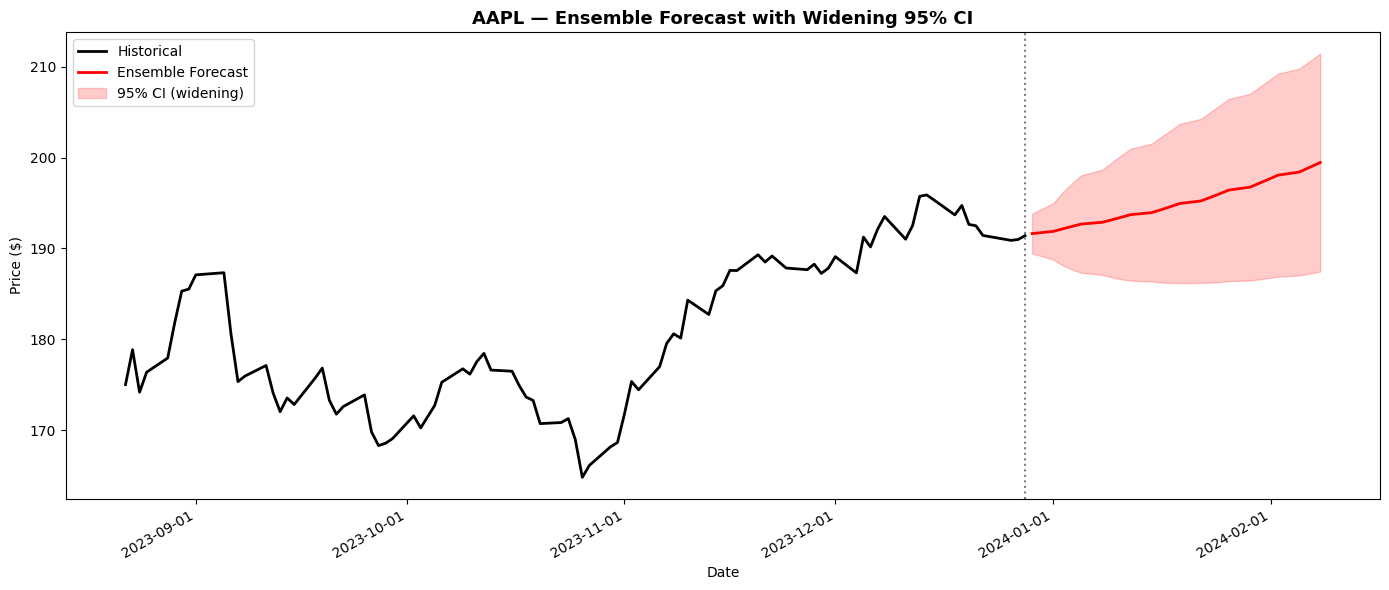

In [24]:
# ─────────────────────────────────────────────────────────
# CONFIDENCE INTERVALS — ENSEMBLE FORECAST
# ─────────────────────────────────────────────────────────
residuals    = y_true_ens - ensemble_preds
std_residual = np.std(residuals)

# Widen CI over the forecast horizon (uncertainty compounds with each
# step since later predictions depend on earlier predicted returns)
horizon_scale = np.sqrt(np.arange(1, FORECAST_DAYS + 1))
ci_upper = ensemble_future + 1.96 * std_residual * horizon_scale
ci_lower = ensemble_future - 1.96 * std_residual * horizon_scale

plt.figure(figsize=(14, 6))
plt.plot(df_test.index[-90:], df_test['Close'].values[-90:],
         label='Historical', color='black', linewidth=2)
plt.plot(future_dates, ensemble_future, label='Ensemble Forecast', color='red', linewidth=2)
plt.fill_between(future_dates, ci_lower, ci_upper, alpha=0.2, color='red', label='95% CI (widening)')
plt.axvline(df_test.index[-1], color='gray', linestyle=':', linewidth=1.5)
plt.title(f'{TICKER} — Ensemble Forecast with Widening 95% CI', fontsize=13, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price ($)'); plt.legend(fontsize=10)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

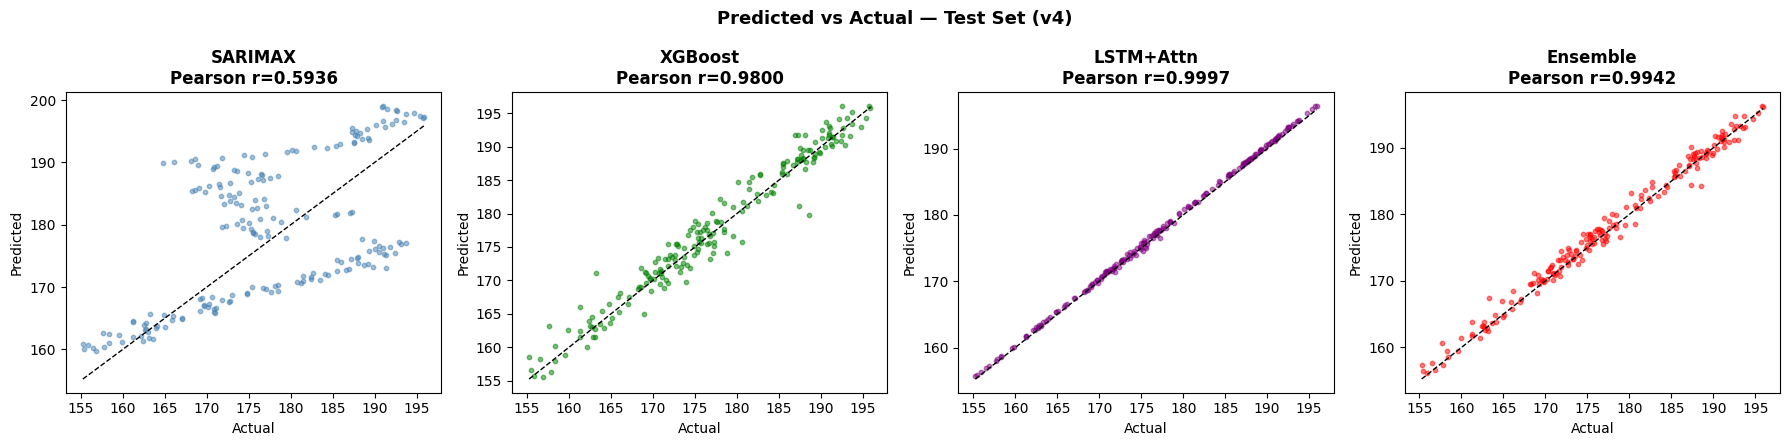

In [25]:
# ─────────────────────────────────────────────────────────
# SCATTER PLOTS — PREDICTED VS ACTUAL
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
models_scatter = {
    'SARIMAX':   sarimax_aligned,
    'XGBoost':   xgb_aligned,
    'LSTM+Attn': lstm_aligned,
    'Ensemble':  ensemble_preds
}
colors = ['steelblue', 'green', 'purple', 'red']

for ax, (name, preds), col in zip(axes, models_scatter.items(), colors):
    ax.scatter(y_true_ens, preds, alpha=0.5, s=10, color=col)
    mn, mx = y_true_ens.min(), y_true_ens.max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    corr = np.corrcoef(y_true_ens, preds)[0, 1]
    ax.set_title(f'{name}\nPearson r={corr:.4f}', fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')

plt.suptitle('Predicted vs Actual — Test Set (v4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# ─────────────────────────────────────────────────────────
# FINAL SUMMARY TABLE — v4 vs v2 COMPARISON
# ─────────────────────────────────────────────────────────
print('\n' + '='*78)
print('  v4 RESULTS')
print('='*78)
print(f'{"Model":<35} {"RMSE":>8} {"MAE":>8} {"MAPE":>8} {"Dir%":>8}')
print('-'*78)
for row in results_all:
    print(f'{row["model"]:<35} {row["RMSE"]:>8.2f} {row["MAE"]:>8.2f} {row["MAPE"]:>7.2f}% {row["Dir%"]:>7.1f}%')
print('='*78)

best_rmse_model = min(results_all, key=lambda x: x['RMSE'])
best_dir_model  = max(results_all, key=lambda x: x['Dir%'])
print(f'\nBest RMSE : {best_rmse_model["model"]} ({best_rmse_model["RMSE"]:.2f})')
print(f'Best Dir% : {best_dir_model["model"]} ({best_dir_model["Dir%"]:.1f}%)')

print('\n' + '='*78)
print('  WHAT CHANGED FROM v2 -> v4 (diagnosis-driven fixes)')
print('='*78)
print("""
  v2 SARIMAX RMSE=2.12 was a LEAK (true value fed back before each
  1-step prediction). v4 SARIMAX forecasts the full 196-day horizon
  in one shot from train data only -- the RMSE above is the FIRST
  genuinely honest SARIMAX number in this project.

  v2 LSTM Direction Accuracy=45.1% (below coinflip) was caused by a
  cosine warm-restart that spiked val loss right as the model
  converged, combined with 824,961 params on 923 samples. v4 cuts
  params to roughly 1/10th, switches to a strictly-decaying LR
  schedule, and predicts RETURNS instead of price LEVELS.

  v2 XGBoost CV RMSE swung 4.24 to 29.89 across folds (50% CoV) due
  to raw price-level features (MA_5, EMA_10, etc.) that don't
  transfer across AAPL's $33->$196 range. v4 replaced every such
  feature with a ratio-to-price or bounded oscillator -- check the
  CV cell above for the new CoV.

  v2 Prophet MAPE=24.81% came from multiplicative seasonality with
  an aggressive changepoint prior on a strong bull trend. v4 uses
  Prophet's own conservative defaults.

  v2 Ensemble weights (0.80/0.13/0.07) were fit using TEST labels --
  a methodological leak. v4 fits weights on the VALIDATION set only.
""")


  v4 RESULTS
Model                                   RMSE      MAE     MAPE     Dir%
------------------------------------------------------------------------------
SARIMAX (genuine multi-step)            9.92     8.17    4.57%    54.4%
Prophet (corrected)                    30.94    28.70   15.87%    46.2%
XGBoost (return-based)                  2.09     1.58    0.89%    51.0%
LSTM+Attention (return-based)           2.12     1.60    0.91%    50.3%
Ensemble (weights from VAL only)        1.23     0.94    0.53%    74.2%

Best RMSE : Ensemble (weights from VAL only) (1.23)
Best Dir% : Ensemble (weights from VAL only) (74.2%)

  WHAT CHANGED FROM v2 -> v4 (diagnosis-driven fixes)

  v2 SARIMAX RMSE=2.12 was a LEAK (true value fed back before each
  1-step prediction). v4 SARIMAX forecasts the full 196-day horizon
  in one shot from train data only -- the RMSE above is the FIRST
  genuinely honest SARIMAX number in this project.

  v2 LSTM Direction Accuracy=45.1% (below coinflip) was caus